# Fully Connected Neural Network on MNIST

In this project, a Fully Connected Neural Network (FCNN) is built to classify handwritten digits from the MNIST dataset.

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9. Each image has a size of 28×28 pixels.

The goal of the model is to take an image as input and predict the correct digit class.

This model is an FCNN because it uses only Flatten and Dense layers. It does not use convolution layers.

In [ ]:
import tensorflow as tf

# Load MNIST digit dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# Dataset Shape Check

Before training the model, the dataset shapes were checked to understand the input and label structure.

- `x_train.shape` shows the number and size of training images.
- `x_test.shape` shows the number and size of test images.
- `y_train.shape` and `y_test.shape` show the number of labels.
- `x_train.dtype` shows the data type after normalization.

In [ ]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("x_train dtype:", x_train.dtype)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
y_train shape: (60000,)
y_test shape: (10000,)
x_train dtype: uint8


The training set contains 60,000 images and the test set contains 10,000 images. Each image has a size of 28×28 pixels. The labels are one-dimensional because each image has one digit label.

# Model Components

The FCNN model consists of the following components:

- **Input layer:** Receives a 28×28 MNIST image.
- **Flatten layer:** Converts the 28×28 image into 784 input values.
- **Dense hidden layer 1:** Contains 128 neurons and uses ReLU activation.
- **Dense hidden layer 2:** Contains 64 neurons and uses ReLU activation.
- **Output layer:** Contains 10 neurons, one for each digit class from 0 to 9.
- **Softmax activation:** Converts the output values into class probabilities.

The model is compiled with:

- **Optimizer:** Adam  
- **Loss function:** Sparse categorical crossentropy  
- **Metric:** Accuracy  

Adam updates the model weights during training. Sparse categorical crossentropy is used because this is a multi-class classification problem with integer labels. Accuracy shows the percentage of correct predictions.

In [ ]:
import tensorflow as tf



# Load MNIST digit dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build a Fully Connected Neural Network
fcnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(name="flatten_28x28_to_784"),
    tf.keras.layers.Dense(128, activation="relu", name="hidden_dense_1"),
    tf.keras.layers.Dense(64, activation="relu", name="hidden_dense_2"),
    tf.keras.layers.Dense(10, activation="softmax", name="output_layer")
])

fcnn_model.compile(optimizer="adam",
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

fcnn_model.summary()

# Train the model
history = fcnn_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = fcnn_model.evaluate(x_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_28x28_to_784 (Flatten)  │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6758 - loss: 1.0202 - val_accuracy: 0.8393 - val_loss: 0.5467
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8661 - loss: 0.4645 - val_accuracy: 0.8938 - val_loss: 0.3727
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8953 - loss: 0.3659 - val_accuracy: 0.9062 - val_loss: 0.3274
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9060 - loss: 0.3276 - val_accuracy: 0.9137 - val_loss: 0.2964
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9133 - loss: 0.3003 - val_accuracy: 0.9224 - val_loss: 0.2696
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9194 - loss: 0.2761 - val_accuracy: 0.9282 - val_loss: 0.2524
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9261 - loss: 0.2549 - val_accuracy: 0.9305 - val_loss: 0.2378
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9313 - loss: 0.2347 -

# Results and Evaluation

After training the FCNN model for 10 epochs, the model reached high accuracy on the MNIST test set.

The final test results were approximately:

- **Test accuracy:** 97.5%
- **Test loss:** 0.098

The graphs below show the training performance of the model.

The accuracy graph shows that both training accuracy and validation accuracy increased during training. This means the model learned the digit patterns successfully.

The loss graph shows that training loss decreased over time. Validation loss stayed relatively low, although it slightly increased near the final epochs. This may indicate a small sign of overfitting, but the overall performance is still strong.

In conclusion, the FCNN model performed well on the MNIST digit classification task. Since MNIST is a relatively simple image dataset, even a basic Fully Connected Neural Network can achieve high accuracy.

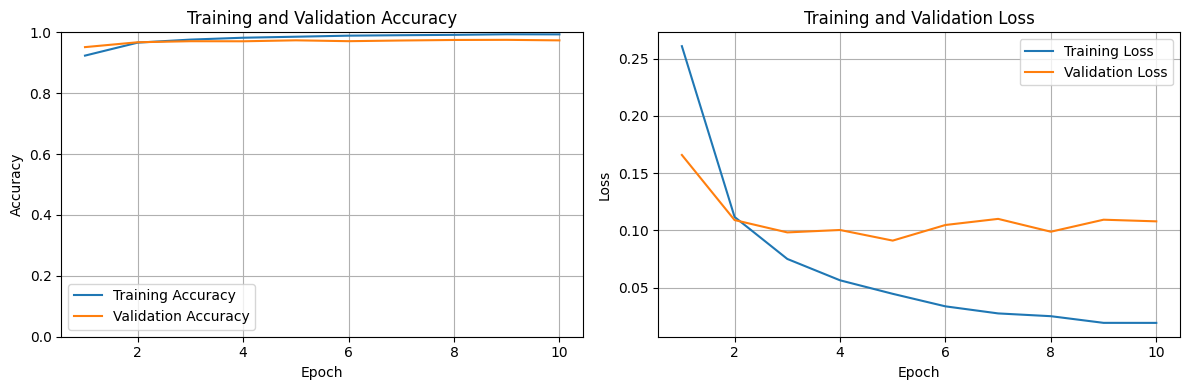

In [ ]:
import matplotlib.pyplot as plt

# Accuracy and loss values
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

# 1) Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# 2) Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Sample MNIST Images

The images below show examples from the MNIST training dataset.

Each image is a grayscale handwritten digit with a size of 28×28 pixels.  
The label above each image shows the correct digit class.

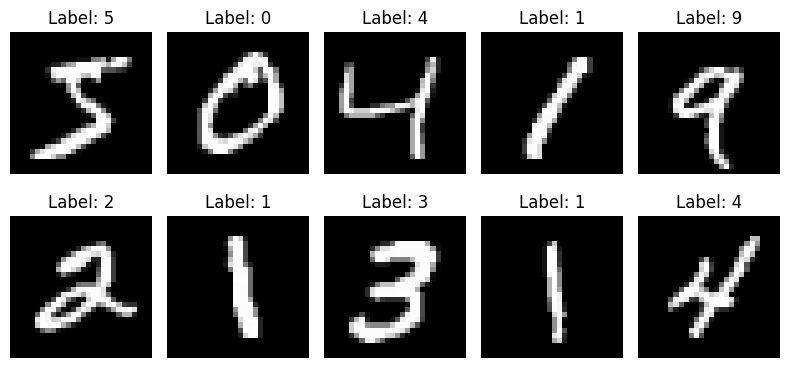

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Model Prediction Example

In this step, the trained FCNN model makes a prediction on one image from the test set.

The model outputs probabilities for each digit class from 0 to 9.  
The class with the highest probability is selected as the predicted label.

The predicted label is compared with the true label to check whether the model classified the image correctly.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


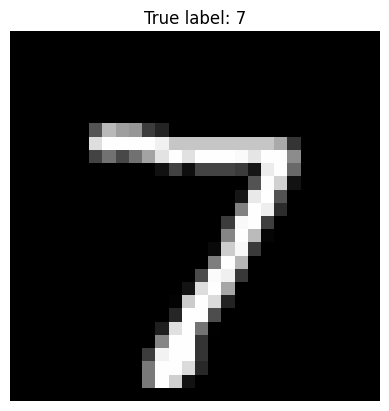

Predicted label: 7
True label: 7


In [ ]:
predictions = fcnn_model.predict(x_test)

index = 0

plt.imshow(x_test[index], cmap='gray')
plt.title(f"True label: {y_test[index]}")
plt.axis('off')
plt.show()

predicted_label = predictions[index].argmax()

print("Predicted label:", predicted_label)
print("True label:", y_test[index])

# Model Evaluation on Test Data

After training, the FCNN model is evaluated on the test dataset.

The test set was not used directly for training. It is used at the end to measure how well the trained model performs on unseen data.

The evaluation returns two values:

- **Test loss:** Measures the prediction error on the test set.
- **Test accuracy:** Shows the percentage of correctly classified test images.

In [ ]:
test_loss, test_accuracy = fcnn_model.evaluate(x_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0940
Test loss: 0.09395965933799744
Test accuracy: 0.9763000011444092


# Prediction Probabilities

The model returns a probability value for each digit class from 0 to 9.  
The highest probability represents the predicted class.

In [ ]:
x_new = x_test[:3]
predict_x = fcnn_model.predict(x_new)

print("Prediction probabilities:")
print(predict_x.round(2))

print("Predicted classes:")
print(predict_x.argmax(axis=1))

print("True labels:")
print(y_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction probabilities:
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Predicted classes:
[7 2 1]
True labels:
[7 2 1]
